/tmp/ipykernel_12091/3120378268.py:56: RuntimeWarning: invalid value encountered in sqrt
  p_star = np.sqrt(M**2/4 - mass**2)


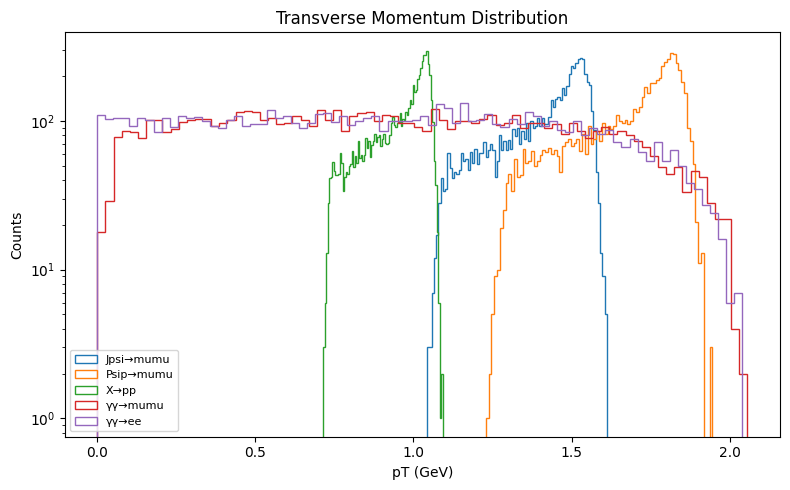

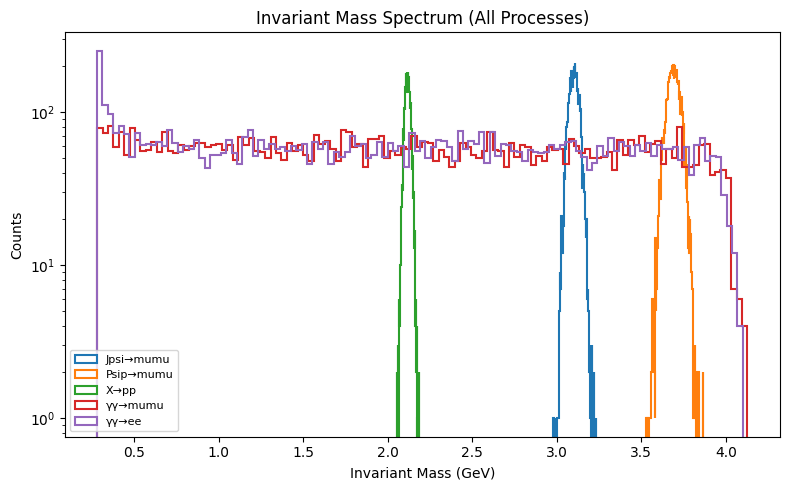

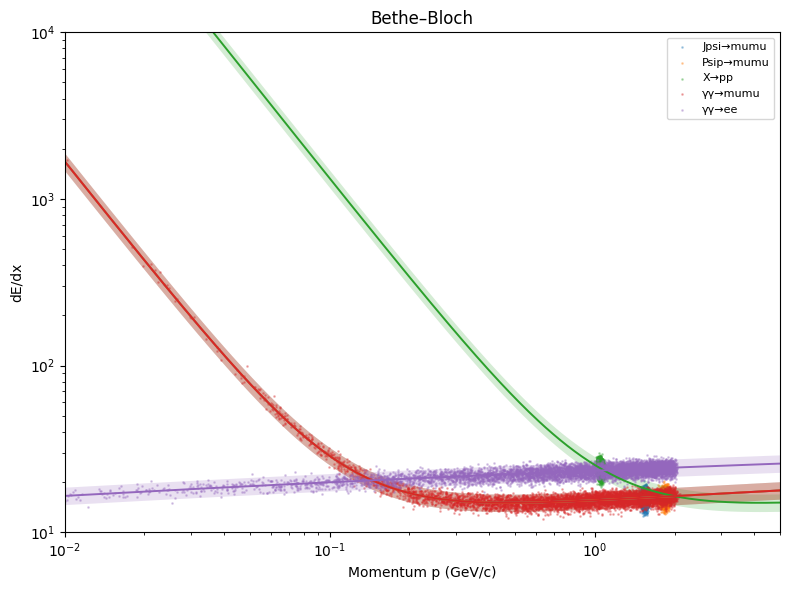

In [6]:
from math import pi

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

m = {
    "pi": 0.13957,
    "mu": 0.10566,
    "e": 0.000511,
    "p": 0.93827,
    "rho": 0.775,
    "K": 0.49367,
    "rho_width": 0.149,
    "Jpsi": 3.0969,
    "Psip": 3.686,
}


def breit_wigner(mass0, width, size):
    gamma = width / 2
    return mass0 + gamma * np.tan(np.pi * (np.random.rand(size) - 0.5))


def two_body_decay(N, M, m1, m2, label):
    p_star = np.sqrt((M**2 - (m1+m2)**2)*(M**2 - (m1-m2)**2)) / (2*M)

    costh = 2*np.random.rand(N) - 1
    th = np.arccos(costh)
    phi = 2*np.pi*np.random.rand(N)

    px1 = p_star * np.sin(th) * np.cos(phi)
    py1 = p_star * np.sin(th) * np.sin(phi)
    pz1 = p_star * np.cos(th)

    px2 = -px1
    py2 = -py1
    pz2 = -pz1

    df = pd.DataFrame({
        "process": label,
        "px1": px1, "py1": py1, "pz1": pz1,
        "px2": px2, "py2": py2, "pz2": pz2
    })

    df["eta1"] = 0.5*np.log((np.sqrt(px1**2+py1**2+pz1**2)+pz1) / (np.sqrt(px1**2+py1**2+pz1**2)-pz1 + 1e-9))
    df["eta2"] = -df["eta1"]

    return df



def gamma_gamma_to_pair(N, mass, label, mmin=0, mmax=4):
    M = np.random.uniform(mmin, mmax, size=N)
    p_star = np.sqrt(M**2/4 - mass**2)
    valid = p_star > 0

    M = M[valid]
    p_star = p_star[valid]
    N = len(M)

    costh = 2*np.random.rand(N)-1
    th = np.arccos(costh)
    phi = 2*np.pi*np.random.rand(N)

    px1 = p_star * np.sin(th)*np.cos(phi)
    py1 = p_star * np.sin(th)*np.sin(phi)
    pz1 = p_star * np.cos(th)

    px2 = -px1
    py2 = -py1
    pz2 = -pz1

    df = pd.DataFrame({
        "process": label,
        "px1": px1, "py1": py1, "pz1": pz1,
        "px2": px2, "py2": py2, "pz2": pz2
    })

    df["eta1"] = 0.5*np.log((np.sqrt(px1**2+py1**2+pz1**2)+pz1) /
                            (np.sqrt(px1**2+py1**2+pz1**2)-pz1 + 1e-9))
    df["eta2"] = -df["eta1"]

    return df


def smear_momentum(df, a=0.01, b=0.007):
    for i in [1,2]:
        p = np.sqrt(df[f"px{i}"]**2 + df[f"py{i}"]**2 + df[f"pz{i}"]**2)
        sigma = np.sqrt(a**2 + (b*p)**2)
        smear = np.random.normal(1, sigma)
        df[f"px{i}"] *= smear
        df[f"py{i}"] *= smear
        df[f"pz{i}"] *= smear
    return df


def bethe_bloch(beta_gamma):
    K = 15.0
    B = 2.0
    C = 1.5
    D = 12.0
    return K/(beta_gamma**B) + C*np.log(beta_gamma) + D

#def compute_pid(df, mass):
#    for i in [1,2]:
#        px = df[f"px{i}"]
#        py = df[f"py{i}"]
#        pz = df[f"pz{i}"]
#        p = np.sqrt(px**2+py**2+pz**2)

#        bg = p / mass
#        dedx = bethe_bloch(bg)

#        dedx *= np.random.normal(1, 0.06, size=len(dedx))
#        df[f"dedx{i}"] = dedx

#    return df

def compute_pid(df):
    # Map each process label to the actual mass of the final-state particles
    process_mass_map = {
        "Jpsi→mumu": m["mu"],
        "Psip→mumu": m["mu"],
        "X→pp": m["p"],
        "γγ→mumu": m["mu"],
        "γγ→ee": m["e"]
    }
    
    for i in [1, 2]:
        px = df[f"px{i}"]
        py = df[f"py{i}"]
        pz = df[f"pz{i}"]
        p = np.sqrt(px**2 + py**2 + pz**2)

        # Dynamically retrieve the correct mass for each row
        mass = df["process"].map(process_mass_map)
        
        bg = p / mass
        dedx = bethe_bloch(bg)

        dedx *= np.random.normal(1, 0.06, size=len(dedx))
        df[f"dedx{i}"] = dedx

    return df



def acceptance(df, eta_max=0.9):
    return df[(np.abs(df["eta1"])<eta_max) & (np.abs(df["eta2"])<eta_max)]


def generate_all(N=5000):
    dfs = []

    # rho → ππ (with Breit-Wigner)
    M_rho = breit_wigner(m["rho"], m["rho_width"], N)
    #for Mi in M_rho:
    #    dfs.append(two_body_decay(1, Mi, m["pi"], m["pi"], "rho→pi pi"))
    #df_rho = pd.concat(dfs, ignore_index=True)

    # J/psi → μμ
    df_jpsi = two_body_decay(N, m["Jpsi"], m["mu"], m["mu"], "Jpsi→mumu")

    # Ψ' → μμ
    df_psip = two_body_decay(N, m["Psip"], m["mu"], m["mu"], "Psip→mumu")

    # proton
    df_pp = two_body_decay(N, 3*m["p"], m["p"], m["p"], "X→pp")

    # gamma-gamma → mu mu / e e
    df_gg_mumu = gamma_gamma_to_pair(N, m["mu"], "γγ→mumu")
    df_gg_ee = gamma_gamma_to_pair(N, m["e"], "γγ→ee")

    df = pd.concat([df_jpsi, df_psip, df_pp, df_gg_mumu, df_gg_ee], ignore_index=True)

    df = smear_momentum(df)

    df = compute_pid(df)

    df = acceptance(df)

    return df



def compute_invariant_mass(df, mass=0.13957):
    
    E1 = np.sqrt(df["px1"]**2 + df["py1"]**2 + df["pz1"]**2 + mass**2)
    E2 = np.sqrt(df["px2"]**2 + df["py2"]**2 + df["pz2"]**2 + mass**2)

    px = df["px1"] + df["px2"]
    py = df["py1"] + df["py2"]
    pz = df["pz1"] + df["pz2"]
    E = E1 + E2

    return np.sqrt(E**2 - (px**2 + py**2 + pz**2))


def QA(df):

    processes = df["process"].unique()
    colors = plt.cm.tab10.colors[:len(processes)]

    plt.figure(figsize=(8,5))

    for proc, col in zip(processes, colors):
        sub = df[df["process"] == proc]

        pt1 = np.sqrt(sub["px1"]**2 + sub["py1"]**2)
        pt2 = np.sqrt(sub["px2"]**2 + sub["py2"]**2)

        plt.hist(pt1, bins=80, color=col, label=f"{proc}", histtype="step")
        #plt.hist(pt2, bins=80, alpha=0.4, color=col,
        #         histtype="step", linestyle="dashed")

    plt.xlabel("pT (GeV)")
    plt.yscale("log")
    plt.ylabel("Counts")
    plt.title("Transverse Momentum Distribution")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,5))

    for proc, col in zip(processes, colors):
        sub = df[df["process"] == proc]

        E1 = np.sqrt(sub["px1"]**2 + sub["py1"]**2 + sub["pz1"]**2 + 0.13957**2)
        E2 = np.sqrt(sub["px2"]**2 + sub["py2"]**2 + sub["pz2"]**2 + 0.13957**2)

        px = sub["px1"] + sub["px2"]
        py = sub["py1"] + sub["py2"]
        pz = sub["pz1"] + sub["pz2"]
        E  = E1 + E2

        M = np.sqrt(np.maximum(E**2 - (px**2 + py**2 + pz**2), 0))

        plt.hist(M, bins=120, histtype="step", linewidth=1.5, color=col, label=proc)

    plt.xlabel("Invariant Mass (GeV)")
    plt.yscale("log")
    plt.ylabel("Counts")
    plt.title("Invariant Mass Spectrum (All Processes)")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(8,6))

    # map each process to a particle type (mu, e, pi, K, p)
    process_particle_map = {
        "Jpsi→mumu": "mu",
        "Psip→mumu": "mu",
        "γγ→mumu":  "mu",
        "γγ→ee":    "e",
        "X→pp":     "p",
        "K":        "K",
        "pi":       "pi"
    }

    # --- unified masses for each particle ---
    particle_mass = {
        "e":  m["e"],
        "mu": m["mu"],
        "pi": m["pi"],
        "K":  m["K"],
        "p":  m["p"]
    }

    # --- universal Bethe–Bloch-like fit model ---
    def fit_func(p_val, mass, K, B, C, D):
        bg = p_val / mass
        return K / (bg**B) + C * np.log(bg) + D

    sigma = 0.06  # same shading factor

    for proc, col in zip(processes, colors):
        sub = df[df["process"] == proc]
        
        # particle type
        ptype = process_particle_map.get(proc, "pi")
        mass = particle_mass[ptype]

        # momenta
        p = np.sqrt(sub["px1"]**2 + sub["py1"]**2 + sub["pz1"]**2)
        mask = p > 1e-3
        p = p[mask]
        p_ref = np.logspace(-2, 0.7, 300)
        dedx = sub["dedx1"][mask]
        dedx_ref = fit_func(p_ref, mass, 15.0, 2.0, 1.5, 12.0)

        # scatter (data)
        plt.scatter(p, dedx, s=1, alpha=0.3, color=col, label=proc)

        # fit the curve
        popt, _ = curve_fit(
            lambda pp, K, B, C, D: fit_func(pp, mass, K, B, C, D),
            p_ref, dedx_ref, p0=[15.0, 2.0, 1.5, 12.0]
        )

        # smooth line
        p_smooth = np.logspace(np.log10(max(p_ref.min(), 1e-3)), np.log10(p_ref.max()), 300)
        dedx_fit = fit_func(p_smooth, mass, *popt)

        # draw line + band (same style for all)
        plt.plot(p_smooth, dedx_fit, color=col, linewidth=1.4)
        plt.fill_between(
            p_smooth,
            dedx_fit * (1 - 2*sigma),
            dedx_fit * (1 + 2*sigma),
            color=col, alpha=0.20, edgecolor='none'
        )
        

    plt.xscale("log")
    plt.xlim(1e-2, 5)
    plt.yscale("log")
    plt.ylim(1e1, 1e4)
    plt.xlabel("Momentum p (GeV/c)")
    plt.ylabel("dE/dx")
    plt.title("Bethe–Bloch")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

df = generate_all(10000)
QA(df)
#print(df.head())
